In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

In [26]:
import pandas as pd

# Load the data you saved in the EDA notebook
df_train = pd.read_csv('../data/cleaned_train.csv')
df_test = pd.read_csv('../data/cleaned_test.csv')

print(f"Data loaded! Train shape: {df_train.shape}")

Data loaded! Train shape: (3602, 5)


In [27]:
# Combine text and aspect to give the model context of which aspect to look at
df_train['combined_text'] = df_train['text'] + " " + df_train['aspect']
df_test['combined_text'] = df_test['text'] + " " + df_test['aspect']

# Define our X (features) and y (labels)
X_train_raw = df_train['combined_text']
y_train_raw = df_train['sentiment']

X_test_raw = df_test['combined_text']
y_test_raw = df_test['sentiment']

print("Example of combined input:", X_train_raw.iloc[0])

Example of combined input: but the staff was so horrible to us. staff


In [28]:
# 1. Check if there are any NaNs in the sentiment column
print("NaNs in Train Sentiment:", df_train['sentiment'].isnull().sum())
print("NaNs in Test Sentiment:", df_test['sentiment'].isnull().sum())

# 2. Drop any rows where sentiment is NaN 
df_train = df_train.dropna(subset=['sentiment'])
df_test = df_test.dropna(subset=['sentiment'])

# 3. Double check the unique values 
print("Cleaned Train Sentiments:", df_train['sentiment'].unique())
print("Cleaned Test Sentiments:", df_test['sentiment'].unique())

# 4. feature variables
X_train_raw = df_train['combined_text'].astype(str)
y_train_raw = df_train['sentiment']

X_test_raw = df_test['combined_text'].astype(str)
y_test_raw = df_test['sentiment']

NaNs in Train Sentiment: 0
NaNs in Test Sentiment: 1134
Cleaned Train Sentiments: <StringArray>
['negative', 'positive', 'neutral']
Length: 3, dtype: str
Cleaned Test Sentiments: []


In [29]:
from sklearn.model_selection import train_test_split

# Split the training data (80/20 split)
train_df, test_df = train_test_split(
    df_train, 
    test_size=0.20, 
    random_state=42, 
    stratify=df_train['sentiment']
)

# Prepare the raw text inputs again
X_train_raw = train_df['text'] + " " + train_df['aspect']
y_train_raw = train_df['sentiment']

X_test_raw = test_df['text'] + " " + test_df['aspect']
y_test_raw = test_df['sentiment']

print(f"New Training Samples: {len(X_train_raw)}")
print(f"New Testing Samples: {len(X_test_raw)}")

New Training Samples: 2881
New Testing Samples: 721


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Re-initialize and fit
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, sublinear_tf=True)
X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

# This should now run without the "nan" error!
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

print("Encoding successful! Labels:", label_encoder.classes_)

Encoding successful! Labels: ['negative' 'neutral' 'positive']


In [31]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# Train
baseline_model = LinearSVC(C=1.0, multi_class='ovr', class_weight='balanced', random_state=42)
baseline_model.fit(X_train, y_train)

# Predict
y_pred = baseline_model.predict(X_test)

# Report
print("--- Classification Report (Validation Split) ---")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")

--- Classification Report (Validation Split) ---
              precision    recall  f1-score   support

    negative       0.52      0.51      0.51       161
     neutral       0.44      0.46      0.45       127
    positive       0.81      0.80      0.81       433

    accuracy                           0.68       721
   macro avg       0.59      0.59      0.59       721
weighted avg       0.68      0.68      0.68       721

Accuracy: 67.68%


In [34]:
import os

os.makedirs('../outputs/graphs', exist_ok=True)
os.makedirs('../outputs/results', exist_ok=True)
print("Folders created!")

Folders created!


C=0.01: 0.6147
C=0.1: 0.7213
C=0.5: 0.7282
C=1.0: 0.7279
C=5.0: 0.7171
C=10.0: 0.7116


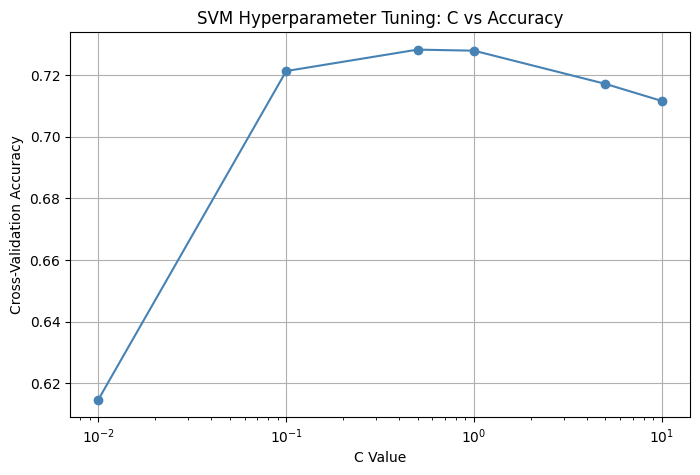


Best C value: 0.5


In [35]:
from sklearn.model_selection import cross_val_score

# Try different C values
C_values = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
accuracies = []

for c in C_values:
    model = LinearSVC(C=c, class_weight='balanced', random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    accuracies.append(scores.mean())
    print(f"C={c}: {scores.mean():.4f}")

# Plot C vs Accuracy — save this for your report
plt.figure(figsize=(8,5))
plt.plot(C_values, accuracies, marker='o', color='steelblue')
plt.xscale('log')
plt.xlabel('C Value')
plt.ylabel('Cross-Validation Accuracy')
plt.title('SVM Hyperparameter Tuning: C vs Accuracy')
plt.grid(True)
plt.savefig('../outputs/graphs/svm_c_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

best_c = C_values[accuracies.index(max(accuracies))]
print(f"\nBest C value: {best_c}")

In [36]:
# Train with best C
final_svm = LinearSVC(C=best_c, class_weight='balanced', 
                      multi_class='ovr', random_state=42)
final_svm.fit(X_train, y_train)
y_pred_final = final_svm.predict(X_test)

print("--- Final SVM Classification Report ---")
print(classification_report(y_test, y_pred_final, target_names=label_encoder.classes_))
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.2%}")

--- Final SVM Classification Report ---
              precision    recall  f1-score   support

    negative       0.52      0.53      0.52       161
     neutral       0.47      0.48      0.47       127
    positive       0.81      0.80      0.81       433

    accuracy                           0.69       721
   macro avg       0.60      0.60      0.60       721
weighted avg       0.69      0.69      0.69       721

Accuracy: 68.52%


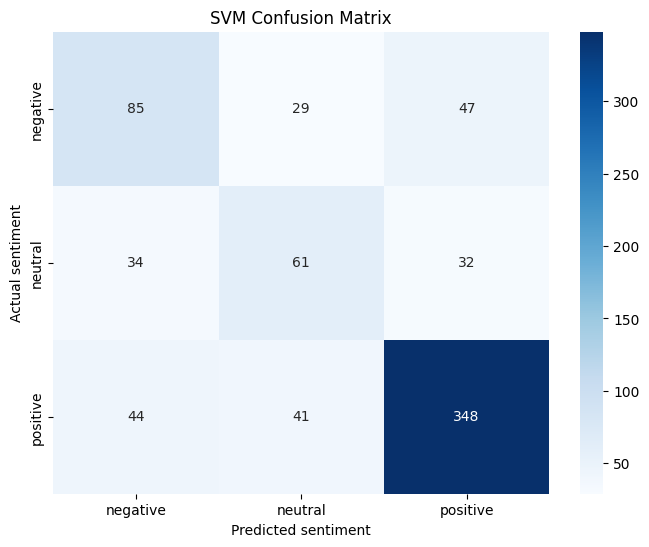

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
            
plt.title('SVM Confusion Matrix')
plt.ylabel('Actual sentiment')
plt.xlabel('Predicted sentiment')
plt.savefig('../outputs/graphs/svm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()